In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Goal 
For 22 unique LPs, we need to calcualte 

1. what do they trade and how are their markouts.

2. What are the top 3 synthetic contracts traded by these LPs in market value?

3. What is the market value of all trades completed for that instrument by the LP?

4. What is the markout for that LPs at different time frames (instant, 10s, 30s, 60s, 1hr, EOD, etc.)

5. calculating the markout with different time lags (immediate, 10s after execution, 30s after execution, 60s after execution, 1hr after execution, 12hr after execution) first, then groupby for LPs, market value of all trades completed for that instrument by the LP

# Data Preprocessing
Trading data: merged_r8fin_trades.parquet

Market data: clob_merged_10s

## Data loading - merged_r8fin_trades

In [3]:
path = "/Users/coffeer/Desktop/merged_r8fin_trades.parquet"
trading_data = pd.read_parquet(path)
trading_data 

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,order_text,quote_or_hedge,hedge_target_price,cash_exchange_trade_id,timestamp,build_id,build_name,hide_duration,pop_ticks,label
0,2024-09-16,2024-09-13 07:15:38.351,NaT,2024-09-13 03:15:38.351,574483.0,550692610,7024116908,696111430.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
1,2024-09-16,2024-09-13 07:15:38.360,NaT,2024-09-13 03:15:38.360,574483.0,550692610,7024116908,696111431.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
2,2024-09-16,2024-09-13 07:15:39.964,NaT,2024-09-13 03:15:39.964,574483.0,550692629,7024116908,696111455.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
3,2024-09-16,2024-09-13 07:15:40.128,NaT,2024-09-13 03:15:40.128,574483.0,550692629,7024116908,696111456.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
4,2024-09-16,2024-09-13 07:15:39.963,NaT,2024-09-13 03:15:39.963,574483.0,550692627,7024116908,696111462.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923554,2024-10-04,2024-10-04 20:59:06.135,2024-10-04 20:59:06.128,2024-10-04 16:59:06.128,590551.0,7029292600,7029291632,699617037.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 29@112.921875), -0.737...",Hedge,98.630859,5629609485429684499,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923555,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.130,2024-10-04 16:59:06.130,590551.0,7029292601,7029291632,699617036.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 57@112.921875), -0.737...",Hedge,98.630859,5629609485429684503,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923556,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.131,2024-10-04 16:59:06.131,590551.0,7029292601,7029291632,699617034.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 57@112.921875), -0.737...",Hedge,98.630859,5629609485429684505,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923557,2024-10-04,2024-10-04 20:59:06.138,2024-10-04 20:59:06.132,2024-10-04 16:59:06.132,590551.0,7029292602,7029291632,699617033.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 43@112.921875), -0.737...",Hedge,98.630859,5629609485429684507,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades


## Data preprocessing - merged_r8fin_trades

### Distribution of Trading Frequency Across Assets 

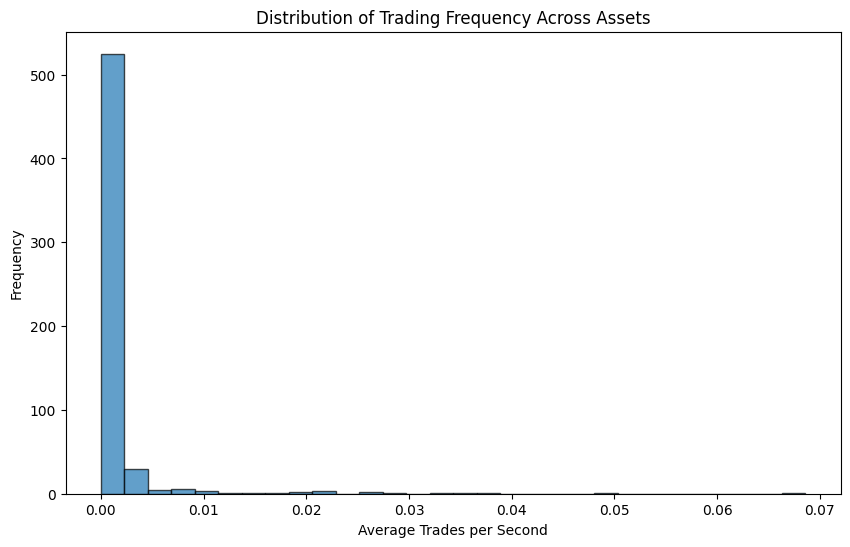

count    5.850000e+02
mean     1.296745e-03
std      5.254958e-03
min      1.280642e-07
25%      6.915468e-06
50%      3.739475e-05
75%      3.310460e-04
max      6.859107e-02
dtype: float64


In [4]:
trading_data['timestamp']= pd.to_datetime(trading_data['timestamp'])

#getting time gap in seconds
trading_data['time_gap'] = trading_data['timestamp'].diff().dt.total_seconds()

# The frequency of trades per second for each asset can be calculated by dividing the number of trades by the total duration in seconds
frequency = trading_data.groupby('symbol').size() / (trading_data['timestamp'].max() - trading_data['timestamp'].min()).total_seconds()\


plt.figure(figsize=(10, 6))
plt.hist(frequency, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Average Trades per Second')
plt.ylabel('Frequency')
plt.title('Distribution of Trading Frequency Across Assets')
plt.show()

print(frequency.describe())

### Order flow aggregation

In [5]:
trading_data['order_flow'] = trading_data['side'].map({'B': 1, 'S': -1}) * trading_data['quantity']
trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')
order_flow_aggregated = trading_data.groupby('time_rounded')['order_flow'].sum().reset_index()
order_flow_aggregated

/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/4130352597.py:2: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')


,time_rounded,order_flow
0,2024-08-02 11:56:30,-17.0
1,2024-08-02 12:03:00,-51.0
2,2024-08-02 12:03:30,-81.0
3,2024-08-02 12:03:40,-23.0
4,2024-08-02 12:33:40,15.0
...,...,...
229171,2024-10-31 20:59:00,-11.0
229172,2024-10-31 20:59:10,-140.0
229173,2024-10-31 20:59:20,4.0
229174,2024-10-31 20:59:30,-20.0


## Data loading - clob_merged_10s

In [6]:
# Load market data for each symbol (example with 7 symbols)
symbols = ['2yr', '3yr', '5yr', '7yr', '10yr', '20yr', '30yr']
market_data = {}
for symbol in symbols:
    market_data[symbol] = pd.read_csv(f'/Users/coffeer/Desktop/clob_merged_10s/{symbol}_combined_result.csv')

## Data preprocessing - clob_merged_10s

### Round the "executiontime" to the nearest 10 seconds to create "executiontime_10s"

In [28]:
# Convert execution time to datetime format
trading_data['executiontime'] = pd.to_datetime(trading_data['executiontime'])

# Round execution time down to the nearest 10 seconds
trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')

/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/1392569256.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')


### Take the data with symbols ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
- Question for feature team: do we need more? What is the difference between __Year O1

In [8]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

# Filter the trading data to include only rows with the selected maturity symbols
filtered_trading_data = trading_data[trading_data['symbol'].isin(maturity_symbols)]

## Merging two dataset based on "executiontime_10s", and "time"

### Merge

In [9]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
market_symbols = ['30yr', '5yr', '2yr', '10yr', '3yr', '7yr', '20yr']

# Create a mapping between trading symbols and market symbols
symbol_mapping = dict(zip(maturity_symbols, market_symbols))

# Create an empty list to store merged data for each symbol
merged_data_list = []

# Loop through each symbol and merge with corresponding market data
for maturity_symbol, market_symbol in symbol_mapping.items():
    # Filter trading data for the current symbol
    trading_data_filtered = filtered_trading_data[filtered_trading_data['symbol'] == maturity_symbol]
    market_data_filtered = market_data[market_symbol].copy()

    # Convert market data time to datetime format
    market_data_filtered['time'] = pd.to_datetime(market_data_filtered['time'])

    # Merge trading data with market data based on exact match of time, including bid/ask size and price
    merged_data = pd.merge(trading_data_filtered, market_data_filtered,
                           left_on='executiontime_10s', right_on='time',
                           how='left')

    # Append merged data to the list
    merged_data_list.append(merged_data)

mapped_data = pd.concat(merged_data_list, ignore_index=True)


### Question for data team: we waste lots of data because the date is not align

In [10]:
trading_data_filtered['executiontime_10s'] 

80836     2024-09-16 08:47:00
80838     2024-09-16 08:47:00
80840     2024-09-16 08:47:00
80843     2024-09-16 08:47:20
80846     2024-09-16 08:47:20
                  ...        
5923481   2024-10-04 20:57:50
5923510   2024-10-04 20:57:50
5923517   2024-10-04 20:58:10
5923518   2024-10-04 20:58:10
5923519   2024-10-04 20:58:10
Name: executiontime_10s, Length: 76921, dtype: datetime64[us]

In [11]:
market_data_filtered['time']

0        2024-07-31 22:22:30
1        2024-07-31 22:22:40
2        2024-07-31 22:22:50
3        2024-07-31 22:23:00
4        2024-07-31 22:23:10
                 ...        
696628   2024-10-31 17:29:20
696629   2024-10-31 17:29:30
696630   2024-10-31 17:29:40
696631   2024-10-31 17:29:50
696632   2024-10-31 17:30:00
Name: time, Length: 696633, dtype: datetime64[ns]

In [12]:
print(min(len(trading_data_filtered), len(market_data_filtered)) - len(merged_data)) 
print(max(len(trading_data_filtered), len(market_data_filtered)) - len(merged_data))

0
619712


# Data Analysis 

### Finding Outlier of slippage

In [13]:
import re

# Function to extract coupon rate as a numeric value
def extract_coupon_rate(instrument):
    match = re.search(r'(\d+\.\d+)%', instrument)
    if match:
        return float(match.group(1))  # Convert matched value to float
    return None  # Return None if no match is found

mapped_data['coupon_rate'] = mapped_data['instrument'].apply(extract_coupon_rate)
mapped_data['coupon_rate'] = mapped_data['coupon_rate']/100

mapped_data['coupon_rate'].dropna()

8132       0.408
8151       0.408
8153       0.408
8159       0.408
8164       0.408
           ...  
1797524    0.305
1797525    0.305
1797526    0.305
1797527    0.305
1797528    0.305
Name: coupon_rate, Length: 1848, dtype: float64

###

### Problem for data team: The regex does not work, which can also be seen from the original file that only 1848 names are valied
Feature team may tell data team the tickets they want to keep then data team can work on finding a proper regex

In [14]:
# Get the top 100 unique instruments
unique_instruments = mapped_data['instrument'].unique().tolist()[:100]

# Apply the extract_coupon_rate function to each instrument
results = [extract_coupon_rate(instr) for instr in unique_instruments]

# Count the number of None values
none_count = sum(1 for r in results if r is None)

# Print the results
print(f"Total instruments: {len(unique_instruments)}")
print(f"Number of None values: {none_count}")
print(f"Number of valid coupon rates: {len(unique_instruments) - none_count}")

Total instruments: 100
Number of None values: 99
Number of valid coupon rates: 1


## Distribution of Coupon Rates (suffer from regex probelm as well)

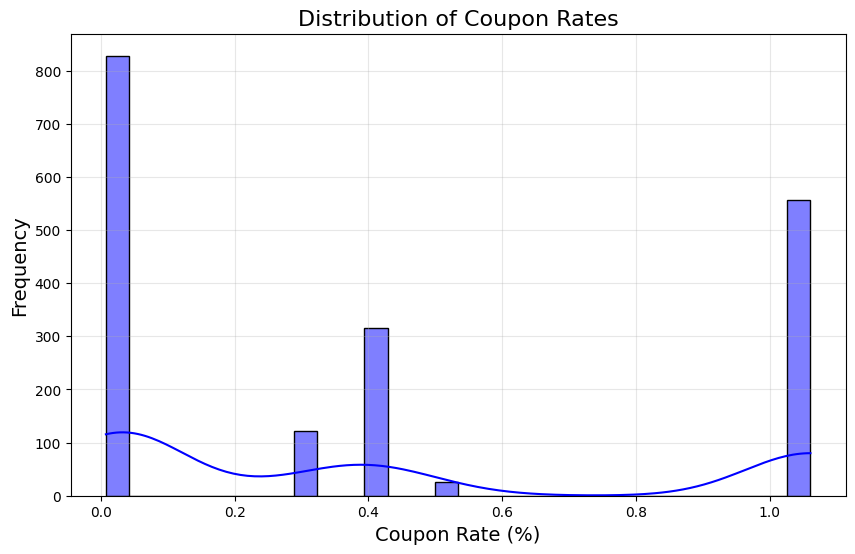

In [15]:
# Drop NA values from coupon_rate
coupon_rates = mapped_data['coupon_rate'].dropna()

# Set up the plot
plt.figure(figsize=(10, 6))

# Histogram with KDE
sns.histplot(coupon_rates, kde=True, bins=30, color='blue', edgecolor='black')

# Add labels and title
plt.title('Distribution of Coupon Rates', fontsize=16)
plt.xlabel('Coupon Rate (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Show plot
plt.grid(alpha=0.3)
plt.show()

## Slippage Outliners 

### Slippage Calculation 

In [17]:
def calculate_slippage(row):
    if row['side'] == 'B':
        return (row['PRICE_YIELD'] - row['MID_yield']) / row['MID_yield'] * 10000
    elif row['side'] == 'S':
        return (row['MID_yield'] - row['PRICE_YIELD']) / row['MID_yield'] * 10000

mapped_data['PRICE_YIELD'] = (mapped_data['coupon_rate'] / mapped_data['price']) * 100
mapped_data['COMP_BID_YIELD'] = (mapped_data['coupon_rate'] / mapped_data['bid_price']) * 100
mapped_data['COMP_ASK_YIELD'] = (mapped_data['coupon_rate'] / mapped_data['ask_price']) * 100

# Calculate MID_yield for mapped_data
mapped_data['MID_yield'] = (mapped_data['COMP_BID_YIELD'] + mapped_data['COMP_ASK_YIELD']) / 2

# Calculate Slippage in Basis Points (bps)
mapped_data['slippage_bps'] = mapped_data.apply(calculate_slippage, axis=1)

### Outliner Dectector 

In [18]:
Q1 = mapped_data['slippage_bps'].quantile(0.25)
Q3 = mapped_data['slippage_bps'].quantile(0.75)
IQR = Q3 - Q1

# Define Outlier Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag Outliers
mapped_data['is_outlier'] = (mapped_data['slippage_bps'] < lower_bound) | \
                            (mapped_data['slippage_bps'] > upper_bound)

# Summary of Outliers
outliers = mapped_data[mapped_data['is_outlier']]
outliers

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,bid_price,ask_size,ask_price,coupon_rate,PRICE_YIELD,COMP_BID_YIELD,COMP_ASK_YIELD,MID_yield,slippage_bps,is_outlier
8132,2024-09-06,2024-09-06 12:57:59.332,2024-09-06 12:57:59.327,2024-09-06 08:57:59.327,569232.0,7022481282,7022480941,694809799.0,SHLYUBUU,YPQBABAQ,...,103.984375,2.0,104.046875,0.408,0.390906,0.392367,0.392131,0.392249,34.245552,True
8151,2024-09-06,2024-09-06 12:58:01.436,2024-09-06 12:58:01.433,2024-09-06 08:58:01.433,569232.0,7022481636,7022480941,694809880.0,SHLYUBUU,YPQBABAQ,...,104.000000,4.0,104.046875,0.408,0.390869,0.392308,0.392131,0.392219,34.429067,True
8153,2024-09-06,2024-09-06 12:58:01.863,2024-09-06 12:58:01.857,2024-09-06 08:58:01.857,569232.0,7022481673,7022480941,694809894.0,SHLYUBUU,YPQBABAQ,...,104.000000,4.0,104.046875,0.408,0.390876,0.392308,0.392131,0.392219,34.242596,True
8159,2024-09-06,2024-09-06 12:58:02.305,2024-09-06 12:58:02.302,2024-09-06 08:58:02.302,569232.0,7022481772,7022480941,694809865.0,SHLYUBUU,YPQBABAQ,...,104.000000,4.0,104.046875,0.408,0.390876,0.392308,0.392131,0.392219,34.242596,True
8164,2024-09-06,2024-09-06 12:58:02.806,2024-09-06 12:58:02.800,2024-09-06 08:58:02.800,569232.0,7022481851,7022480941,694809821.0,SHLYUBUU,YPQBABAQ,...,104.000000,4.0,104.046875,0.408,0.390869,0.392308,0.392131,0.392219,34.429067,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1755348,2024-08-15,2024-08-15 13:41:49.271,2024-08-15 13:41:49.261,2024-08-15 09:41:49.261,552001.0,7017282760,7017258863,690806982.0,JNOGPDBN,CAIUFPKI,...,104.328125,4.0,104.406250,0.305,0.293324,0.292347,0.292128,0.292237,-37.190074,True
1755349,2024-08-15,2024-08-15 13:41:49.288,2024-08-15 13:41:49.275,2024-08-15 09:41:49.275,552001.0,7017282777,7017258863,690806978.0,JNOGPDBN,CAIUFPKI,...,104.328125,4.0,104.406250,0.305,0.293324,0.292347,0.292128,0.292237,-37.190074,True
1755350,2024-08-15,2024-08-15 13:41:50.626,2024-08-15 13:41:50.610,2024-08-15 09:41:50.610,552001.0,7017282825,7017258863,690806967.0,JNOGPDBN,CAIUFPKI,...,104.343750,3.0,104.406250,0.305,0.293319,0.292303,0.292128,0.292216,-37.753378,True
1755351,2024-08-15,2024-08-15 13:41:52.754,2024-08-15 13:41:52.744,2024-08-15 09:41:52.744,552001.0,7017282906,7017258863,690807016.0,JNOGPDBN,CAIUFPKI,...,104.343750,3.0,104.406250,0.305,0.293324,0.292303,0.292128,0.292216,-37.941923,True


## LP Markout Analysis 

### Count multi-leg trades 
I’m questioning a code's logic for identifying multi-leg trades. It groups trades by 10-second intervals (executiontime_10s) instead of exact execution times but uses syntheticcontractdefinition to verify multi-leg trades. Does this approach properly identify trades, or could it misclassify them due to the grouping logic?

In [27]:
symbols_list = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
selected_data = mapped_data[mapped_data['symbol'].isin(symbols_list)]

In [20]:
# Count the number of unique trades using 'orderid' or 'executionid'
unique_trades_count = selected_data['orderid'].nunique()

multi_leg_trades = selected_data[
    selected_data['syntheticcontractidentifier'].notna() |
    selected_data['syntheticcontractdefinition'].notna()
]

multi_leg_trades_count = multi_leg_trades['orderid'].nunique()

print(f"Total unique trades: {unique_trades_count}")
print(f"Total multi-leg trades: {multi_leg_trades_count}")

Total unique trades: 1438723
Total multi-leg trades: 1435009


### Count hedge trade or regular trade 

In [21]:
# Count the number of unique LPs in the dataset
unique_lps_count = selected_data['exchange_lp'].nunique()
print(f"Total unique LPs in the dataset: {unique_lps_count}")

# Count the number of hedge trades versus regular trades
hedge_trades = selected_data[selected_data['quote_or_hedge'] == 'Hedge']
hedge_trades_count = hedge_trades['orderid'].nunique()
regular_trades_count = unique_trades_count - hedge_trades_count

print(f"Number of hedge trades: {hedge_trades_count}")
print(f"Number of regular trades: {regular_trades_count}")

Total unique LPs in the dataset: 22
Number of hedge trades: 630763
Number of regular trades: 807960


### Calculate the Net order flow for '10S', '30S', '60S', '1H', EOD

In [22]:
symbols_list = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
selected_data = mapped_data[mapped_data['symbol'].isin(symbols_list)]
selected_data['timestamp'] = pd.to_datetime(selected_data['timestamp'])

# Create a 'order_flow' column as you did earlier
selected_data['order_flow'] = selected_data['side'].map({'B': 1, 'S': -1}) * selected_data['quantity']

# 1. Instant (no aggregation)
# Each individual trade is considered its own "instant"
instant_data = selected_data[['timestamp', 'order_flow']]

# 2. 10s, 30s, 60s, 1hr intervals (round to nearest time period and aggregate)
time_intervals = ['10S', '30S', '60S', '1H']  # 10 seconds, 30 seconds, 1 minute (60 seconds), 1 hour

# Round the timestamp to the nearest time interval and group by it
for interval in time_intervals:
    selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval
    aggregated_data = selected_data.groupby('time_rounded')['order_flow'].sum().reset_index()
    print(f"Order flow aggregated by {interval}:")
    print(aggregated_data.head())

# 3. EOD (End of Day)
# Group by the date (ignoring time) and aggregate order flow for each day
selected_data['date'] = selected_data['timestamp'].dt.date  # Extract date part
eod_data = selected_data.groupby('date')['order_flow'].sum().reset_index()
print("Order flow aggregated by End of Day (EOD):")
print(eod_data.head())

/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/1585241118.py:17: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval
/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/1585241118.py:17: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval
/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/1585241118.py:17: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval
/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/1585241118.py:17: FutureWarning: 'H' is deprecated and will be re

Order flow aggregated by 10S:
         time_rounded  order_flow
0 2024-08-04 23:44:40        -1.0
1 2024-08-04 23:44:50        -4.0
2 2024-08-04 23:45:00        -8.0
3 2024-08-04 23:45:10        -1.0
4 2024-08-04 23:45:30        -1.0
Order flow aggregated by 30S:
         time_rounded  order_flow
0 2024-08-04 23:44:30        -5.0
1 2024-08-04 23:45:00        -9.0
2 2024-08-04 23:45:30        -1.0
3 2024-08-04 23:51:00        -3.0
4 2024-08-04 23:52:00         0.0
Order flow aggregated by 60S:
         time_rounded  order_flow
0 2024-08-04 23:44:00        -5.0
1 2024-08-04 23:45:00       -10.0
2 2024-08-04 23:51:00        -3.0
3 2024-08-04 23:52:00         0.0
4 2024-08-04 23:53:00        -4.0
Order flow aggregated by 1H:
         time_rounded  order_flow
0 2024-08-04 23:00:00       -22.0
1 2024-08-05 00:00:00        28.0
2 2024-08-05 01:00:00      -100.0
3 2024-08-05 02:00:00        -8.0
4 2024-08-05 03:00:00       -91.0
Order flow aggregated by End of Day (EOD):
         date  order_f

### The top 3 synthetic contracts traded by the LPs in market value

In [24]:
selected_data['timestamp'] = pd.to_datetime(selected_data['timestamp'])

selected_data['order_flow'] = selected_data['side'].map({'B': 1, 'S': -1}) * selected_data['quantity']

selected_data['market_value'] = selected_data['quantity'] * selected_data['price']

top_3_contracts = selected_data.groupby(['exchange_lp', 'instrument'])['market_value'].sum().reset_index()
top_3_contracts = top_3_contracts.sort_values(by='market_value', ascending=False)

# Find the top 3 contracts for each LP
top_3_per_lp = top_3_contracts.groupby('exchange_lp').head(3).reset_index(drop=True)
print("Top 3 synthetic contracts traded by each LP in market value:")
print(top_3_per_lp)

Top 3 synthetic contracts traded by each LP in market value:
   exchange_lp              instrument  market_value
0     WKWSDLYV            CT5-CT10 (Y)  4.946693e+06
1     WKWSDLYV            CT5-CT30 (Y)  4.414663e+06
2     WKWSDLYV       CT5-CT10-CT30 (Y)  4.410075e+06
3     SBUWHHFR            CT5-CT10 (Y)  2.796593e+06
4     OQFTYCMP            CT5-CT10 (Y)  2.222554e+06
..         ...                     ...           ...
61    XJLFBBMG       CT5-CT10-CT30 (Y)  1.023779e+04
62    HVCLDWPA            CT2-CT10 (Y)  7.195340e+03
63    IMFZQERH  CT3-CT5-CT10 (Y) (DRD)  2.593355e+03
64    IMFZQERH            CT5-CT10 (Y)  6.107188e+02
65    IMFZQERH             CT5-CT7 (Y)  5.088633e+02

[66 rows x 3 columns]


### Market value of all trades completed for that instrument by the LP

In [25]:
market_value_per_instrument = selected_data.groupby(['exchange_lp', 'instrument'])['market_value'].sum().reset_index()
print("Market value of all trades completed by the LP for each instrument:")
print(market_value_per_instrument)

Market value of all trades completed by the LP for each instrument:
      exchange_lp                              instrument  market_value
0        COMENLHK             C23710US20 CLEAN UP ONE OFF    201.431641
1        COMENLHK                           CT10-CNZ4 (Y)    397.808594
2        COMENLHK                        CT10-CT2 65% (Y)    101.550781
3        COMENLHK  CT10-CT2-CT7-CT30 25.2/72/20.7 (Y) (M)    200.158203
4        COMENLHK                           CT10-CT20 (Y)   3990.363281
...           ...                                     ...           ...
13261    YJNXEXOX               UXYZ4-CT20-WNZ4 25/75 FLY    101.615234
13262    YJNXEXOX                          UXYZ4-CT30 (Y)    103.455078
13263    YJNXEXOX                           WNU4-CT30 (Y)    919.960938
13264    YJNXEXOX                           WNZ4-CT30 (Y)   6531.263672
13265    YJNXEXOX                              sprd:3-Z3N    499.089844

[13266 rows x 3 columns]


### What is the markout for that LPs at different time frames (instant, 10s, 30s, 60s, 1hr, EOD, etc.)

In [26]:
time_intervals = ['10S', '30S', '60S', '1H']  # 10 seconds, 30 seconds, 1 minute (60 seconds), 1 hour

# Aggregate markout for each LP and time interval
for interval in time_intervals:
    selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)
    # Assuming you have a markout function to calculate markout at each interval
    aggregated_markout = selected_data.groupby(['exchange_lp', 'time_rounded'])['market_value'].sum().reset_index()
    print(f"Market value and markout aggregated by {interval}:")
    print(aggregated_markout.head())

# For EOD (End of Day) aggregation
selected_data['date'] = selected_data['timestamp'].dt.date  # Extract date part
eod_data = selected_data.groupby(['exchange_lp', 'date'])['market_value'].sum().reset_index()
print("Market value aggregated by End of Day (EOD):")
print(eod_data.head())

/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/3261905328.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)


Market value and markout aggregated by 10S:
  exchange_lp        time_rounded  market_value
0    COMENLHK 2024-08-05 12:14:30    102.240234
1    COMENLHK 2024-08-05 12:27:30    220.488281
2    COMENLHK 2024-08-05 12:37:10    607.898438
3    COMENLHK 2024-08-05 12:37:20    303.972656
4    COMENLHK 2024-08-05 13:16:10    105.632812
Market value and markout aggregated by 30S:
  exchange_lp        time_rounded  market_value
0    COMENLHK 2024-08-05 12:14:30    102.240234
1    COMENLHK 2024-08-05 12:27:30    220.488281
2    COMENLHK 2024-08-05 12:37:00    911.871094
3    COMENLHK 2024-08-05 13:16:00    105.632812
4    COMENLHK 2024-08-05 14:51:30    109.832031


/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/3261905328.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)
/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/3261905328.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)


Market value and markout aggregated by 60S:
  exchange_lp        time_rounded  market_value
0    COMENLHK 2024-08-05 12:14:00    102.240234
1    COMENLHK 2024-08-05 12:27:00    220.488281
2    COMENLHK 2024-08-05 12:37:00    911.871094
3    COMENLHK 2024-08-05 13:16:00    105.632812
4    COMENLHK 2024-08-05 14:51:00    109.832031
Market value and markout aggregated by 1H:
  exchange_lp        time_rounded  market_value
0    COMENLHK 2024-08-05 12:00:00   1234.599609
1    COMENLHK 2024-08-05 13:00:00    105.632812
2    COMENLHK 2024-08-05 14:00:00    318.308594
3    COMENLHK 2024-08-05 15:00:00    101.822266
4    COMENLHK 2024-08-05 16:00:00    514.828125


/var/folders/kv/x8qrhxbj6gxf4kw707c07yvc0000gn/T/ipykernel_74206/3261905328.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)


Market value aggregated by End of Day (EOD):
  exchange_lp        date  market_value
0    COMENLHK  2024-08-05   2376.144531
1    COMENLHK  2024-08-06   5067.734375
2    COMENLHK  2024-08-07   8543.148438
3    COMENLHK  2024-08-08   5426.673828
4    COMENLHK  2024-08-09   9946.894531


# Questions for each teams:
## Feature Team:
- Do we need symbols other than do we need symbols other than ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']? (Data preprocessing - clob_merged_10s)
- What is the difference between __Year O1? (Data preprocessing - clob_merged_10s)
- Feature team may tell data team the tickets they want to include for Slippage outliner (Data Analysis)
- Thinking about if the logic for count multi-leg trades make sense (count multi-leg trades)
## Data Team: 
- Match the timestamp (Merge)
- Thinking about a proper regex for ticket selection (Data Analysis)
- Thinking about if the logic for count multi-leg trades make sense (count multi-leg trades)